# Proyecto Final - Análisis de Datos
## Predicción de Precios de Alquiler en Estados Unidos

**Dataset:** Apartamentos en Alquiler (USA) - Tema_9.csv  
**Objetivo:** Predecir el precio de alquiler según características del inmueble  
**Universidad de Montevideo**

---

In [1]:
pip install cartopy

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocesamiento y modelado
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

print('✓ Librerías importadas correctamente')

✓ Librerías importadas correctamente


---
## 1. Descripción del Problema

El mercado inmobiliario de alquileres en Estados Unidos presenta una gran variabilidad de precios que depende de múltiples factores.

**Objetivo:** Desarrollar un modelo que prediga el precio de alquiler basándose en:
- Características físicas (habitaciones, baños, tamaño)
- Ubicación geográfica (estado, ciudad, coordenadas)
- Comodidades y servicios

---
## 2. Descripción del Conjunto de Datos

In [3]:
# Cargar el dataset
# IMPORTANTE: Asegúrate de que el archivo Tema_9.csv esté en el mismo directorio
df = pd.read_csv('Resources/Tema_9.csv', encoding = 'latin1', delimiter = ';')

print('='*80)
print('DATASET CARGADO')
print('='*80)
print(f'Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'\nColumnas: {list(df.columns)}')

DATASET CARGADO
Dimensiones: 10,000 filas × 22 columnas

Columnas: ['id', 'category', 'title', 'body', 'amenities', 'bathrooms', 'bedrooms', 'currency', 'fee', 'has_photo', 'pets_allowed', 'price', 'price_display', 'price_type', 'square_feet', 'address', 'cityname', 'state', 'latitude', 'longitude', 'source', 'time']


In [4]:
# Vista previa del dataset
df.head()

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5668626895,housing/rent/apartment,"Studio apartment 2nd St NE, Uhland Terrace NE,...","This unit is located at second St NE, Uhland T...",NaN,NaN,0.0,USD,No,Thumbnail,NaN,790,$790,Monthly,101,NaN,Washington,DC,38.9057,-76.9861,RentLingo,1577359415
1,5664597177,housing/rent/apartment,Studio apartment 814 Schutte Road,"This unit is located at 814 Schutte Road, Evan...",NaN,NaN,1.0,USD,No,Thumbnail,NaN,425,$425,Monthly,106,814 Schutte Rd,Evansville,IN,37.9680,-87.6621,RentLingo,1577017063
2,5668626833,housing/rent/apartment,"Studio apartment N Scott St, 14th St N, Arling...","This unit is located at N Scott St, 14th St N,...",NaN,1.0,0.0,USD,No,Thumbnail,NaN,1390,"$1,390",Monthly,107,NaN,Arlington,VA,38.8910,-77.0816,RentLingo,1577359410
3,5659918074,housing/rent/apartment,Studio apartment 1717 12th Ave,"This unit is located at 1717 12th Ave, Seattle...",NaN,1.0,0.0,USD,No,Thumbnail,NaN,925,$925,Monthly,116,1717 12th Avenue,Seattle,WA,47.6160,-122.3275,RentLingo,1576667743
4,5668626759,housing/rent/apartment,"Studio apartment Washington Blvd, N Cleveland ...","This unit is located at Washington Blvd, N Cle...",NaN,NaN,0.0,USD,No,Thumbnail,NaN,880,$880,Monthly,125,NaN,Arlington,VA,38.8738,-77.1055,RentLingo,1577359401


In [5]:
# Información del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             10000 non-null  int64  
 1   category       10000 non-null  object 
 2   title          10000 non-null  object 
 3   body           10000 non-null  object 
 4   amenities      6451 non-null   object 
 5   bathrooms      9966 non-null   float64
 6   bedrooms       9993 non-null   float64
 7   currency       10000 non-null  object 
 8   fee            10000 non-null  object 
 9   has_photo      10000 non-null  object 
 10  pets_allowed   5837 non-null   object 
 11  price          10000 non-null  int64  
 12  price_display  10000 non-null  object 
 13  price_type     10000 non-null  object 
 14  square_feet    10000 non-null  int64  
 15  address        6673 non-null   object 
 16  cityname       9923 non-null   object 
 17  state          9923 non-null   object 
 18  latitud

---
## 3. Análisis Exploratorio de Datos (EDA)

In [6]:
# Valores nulos
print('VALORES NULOS')
print('='*80)
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df)) * 100
nulos_df = pd.DataFrame({
    'Valores Nulos': nulos,
    'Porcentaje': nulos_pct
})
print(nulos_df[nulos_df['Valores Nulos'] > 0].sort_values('Valores Nulos', ascending=False))

VALORES NULOS
              Valores Nulos  Porcentaje
pets_allowed           4163       41.63
amenities              3549       35.49
address                3327       33.27
cityname                 77        0.77
state                    77        0.77
bathrooms                34        0.34
latitude                 10        0.10
longitude                10        0.10
bedrooms                  7        0.07


In [7]:
# Estadísticas descriptivas
print('ESTADÍSTICAS DESCRIPTIVAS')
print('='*80)
df.describe()

ESTADÍSTICAS DESCRIPTIVAS


,id,bathrooms,bedrooms,price,square_feet,latitude,longitude,time
count,1.000000e+04,9966.000000,9993.000000,10000.000000,10000.000000,9990.000000,9990.000000,1.000000e+04
mean,5.623396e+09,1.380544,1.744021,1486.277500,945.810500,37.695162,-94.652247,1.574891e+09
std,7.021025e+07,0.615410,0.942354,1076.507968,655.755736,5.495851,15.759805,3.762395e+06
min,5.508654e+09,1.000000,0.000000,200.000000,101.000000,21.315500,-158.022100,1.568744e+09
25%,5.509248e+09,1.000000,1.000000,949.000000,649.000000,33.679850,-101.301700,1.568781e+09
50%,5.668610e+09,1.000000,2.000000,1270.000000,802.000000,38.809800,-93.651600,1.577358e+09
75%,5.668626e+09,2.000000,2.000000,1695.000000,1100.000000,41.349800,-82.209975,1.577359e+09
max,5.668663e+09,8.500000,9.000000,52500.000000,40000.000000,61.594000,-70.191600,1.577362e+09


In [8]:
# Análisis de la variable objetivo: PRECIO
print('VARIABLE OBJETIVO: PRICE')
print('='*80)
print(f'Precio Mínimo:        ${df["price"].min():>10,.2f}')
print(f'Precio Máximo:        ${df["price"].max():>10,.2f}')
print(f'Precio Promedio:      ${df["price"].mean():>10,.2f}')
print(f'Precio Mediana:       ${df["price"].median():>10,.2f}')
print(f'Desviación Estándar:  ${df["price"].std():>10,.2f}')

# Distribución geográfica
print('\n' + '='*80)
print('DISTRIBUCIÓN GEOGRÁFICA')
print('='*80)
print(f'Estados únicos:  {df["state"].nunique()}')
print(f'Ciudades únicas: {df["cityname"].nunique()}')

print('\nTop 10 Estados:')
print(df['state'].value_counts().head(10))

print('\nTop 10 Ciudades:')
print(df['cityname'].value_counts().head(10))

VARIABLE OBJETIVO: PRICE
Precio Mínimo:        $    200.00
Precio Máximo:        $ 52,500.00
Precio Promedio:      $  1,486.28
Precio Mediana:       $  1,270.00
Desviación Estándar:  $  1,076.51

DISTRIBUCIÓN GEOGRÁFICA
Estados únicos:  51
Ciudades únicas: 1574

Top 10 Estados:
state
TX    1737
CA     955
WA     519
NC     438
MD     424
NJ     383
GA     372
FL     339
OH     321
CO     318
Name: count, dtype: int64

Top 10 Ciudades:
cityname
Austin           523
Dallas           216
Houston          186
San Antonio      182
Los Angeles      165
Chicago          148
Madison          121
Portland         113
Denver           105
San Francisco    104
Name: count, dtype: int64


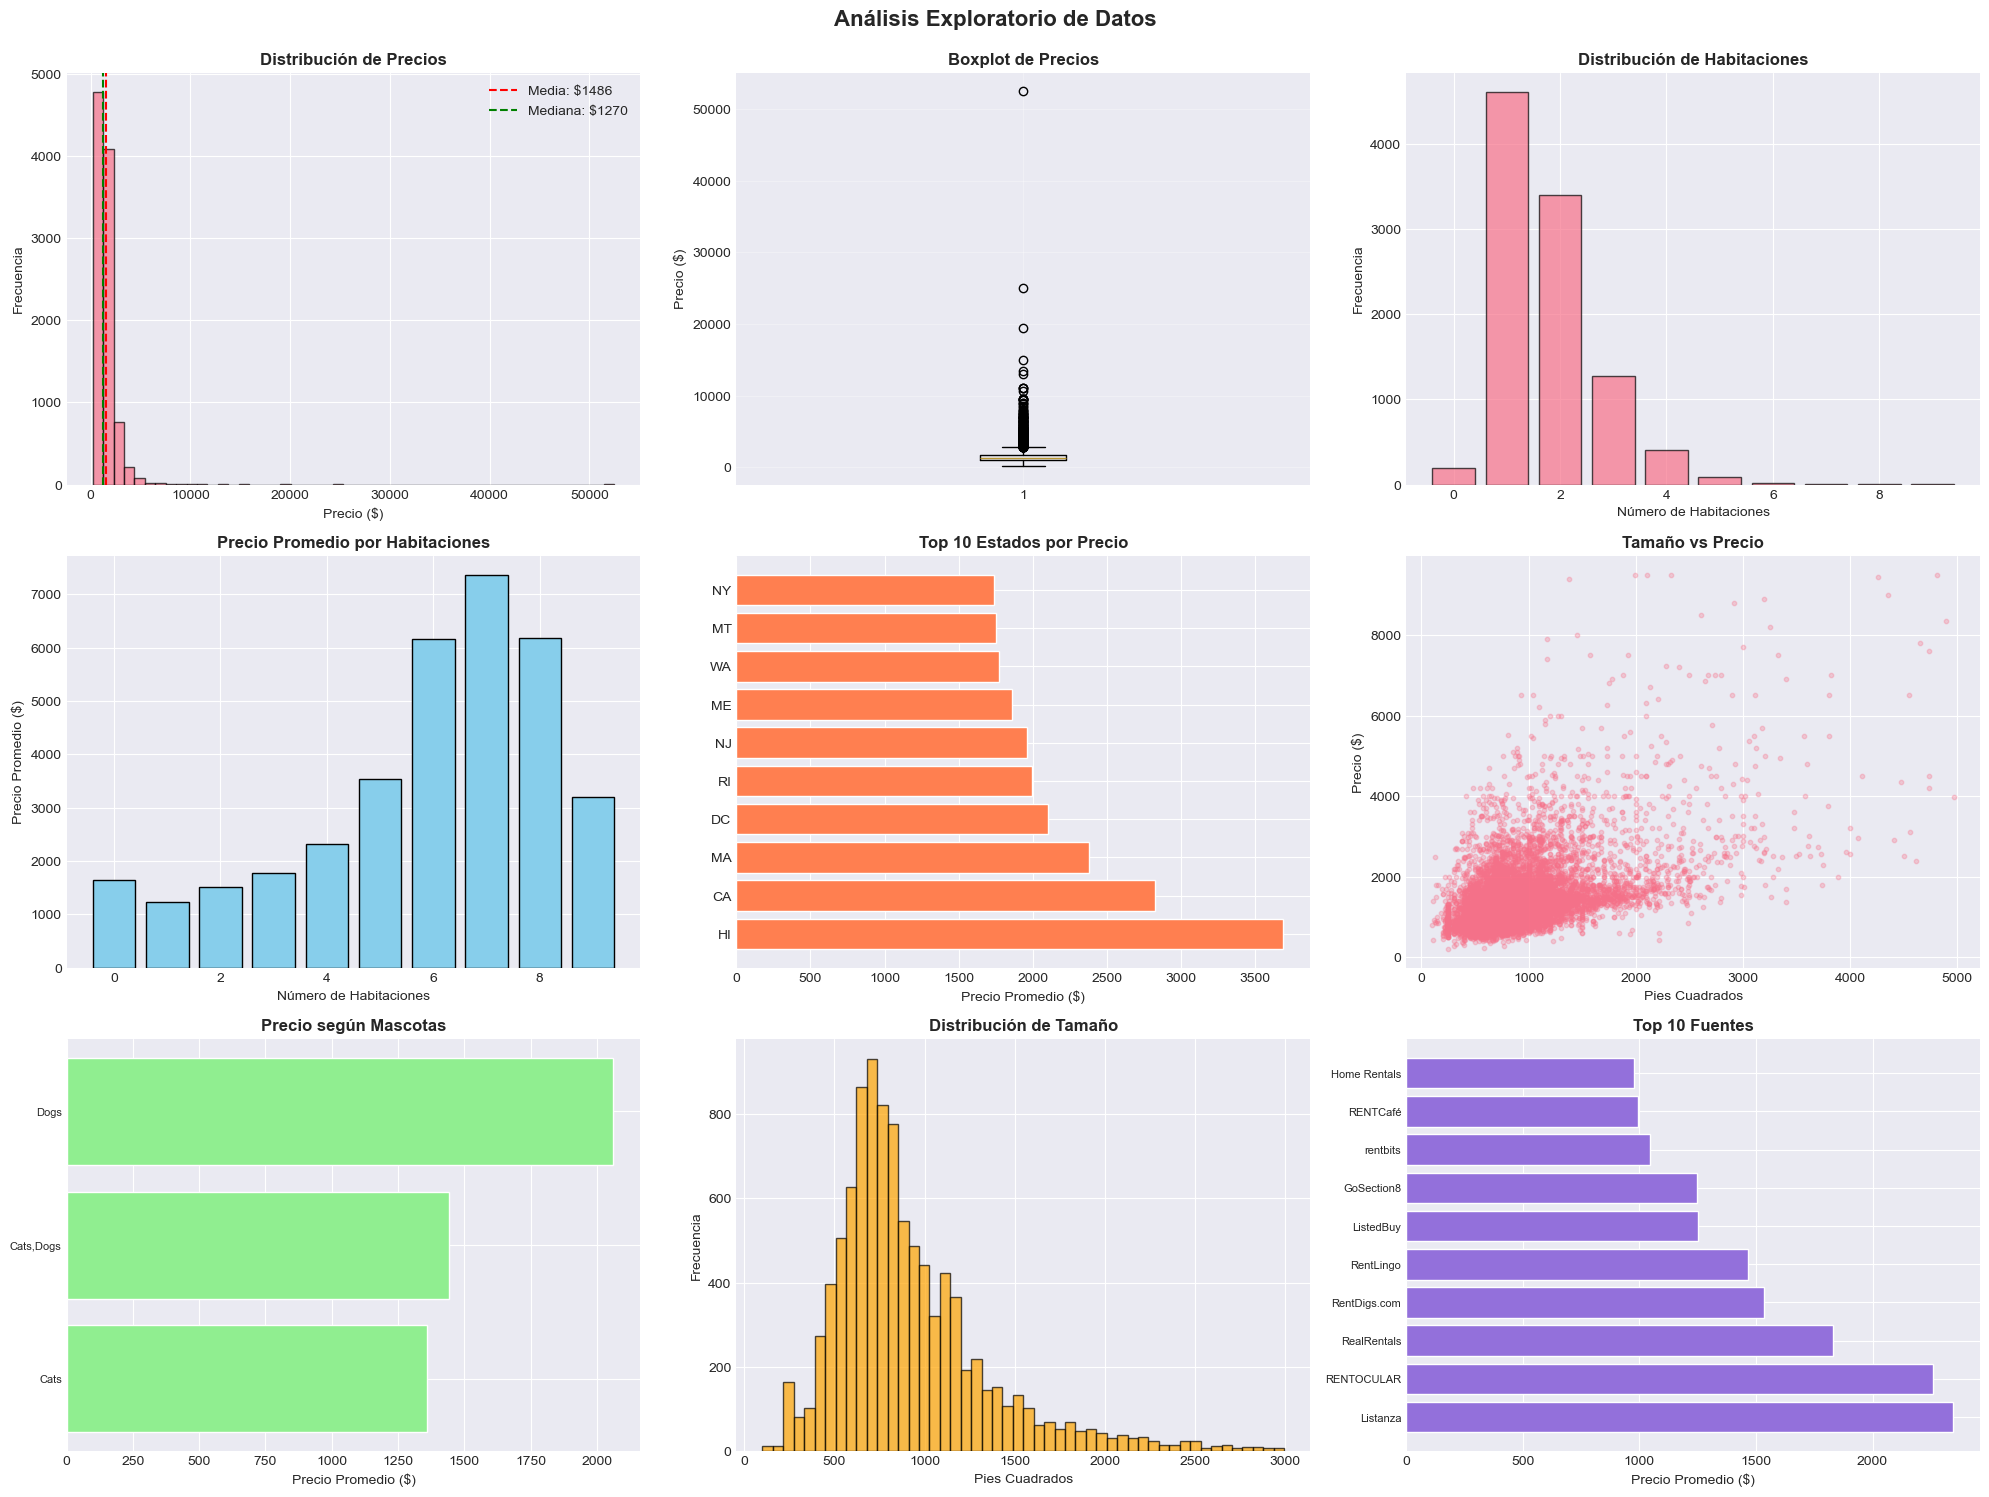

In [9]:
# Visualizaciones exploratorias
fig, axes = plt.subplots(3, 3, figsize=(20, 15))
fig.suptitle('Análisis Exploratorio de Datos', fontsize=16, fontweight='bold', y=0.995)

# 1. Distribución de precios
axes[0, 0].hist(df['price'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df['price'].mean(), color='red', linestyle='--', 
                   label=f'Media: ${df["price"].mean():.0f}')
axes[0, 0].axvline(df['price'].median(), color='green', linestyle='--', 
                   label=f'Mediana: ${df["price"].median():.0f}')
axes[0, 0].set_xlabel('Precio ($)')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Distribución de Precios', fontweight='bold')
axes[0, 0].legend()

# 2. Boxplot de precios
axes[0, 1].boxplot(df['price'], vert=True)
axes[0, 1].set_ylabel('Precio ($)')
axes[0, 1].set_title('Boxplot de Precios', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Distribución de bedrooms
bedrooms_counts = df['bedrooms'].value_counts().sort_index()
axes[0, 2].bar(bedrooms_counts.index, bedrooms_counts.values, edgecolor='black', alpha=0.7)
axes[0, 2].set_xlabel('Número de Habitaciones')
axes[0, 2].set_ylabel('Frecuencia')
axes[0, 2].set_title('Distribución de Habitaciones', fontweight='bold')

# 4. Precio promedio por bedrooms
price_by_bedrooms = df.groupby('bedrooms')['price'].mean().sort_index()
axes[1, 0].bar(price_by_bedrooms.index, price_by_bedrooms.values, 
               color='skyblue', edgecolor='black')
axes[1, 0].set_xlabel('Número de Habitaciones')
axes[1, 0].set_ylabel('Precio Promedio ($)')
axes[1, 0].set_title('Precio Promedio por Habitaciones', fontweight='bold')

# 5. Top 10 estados por precio promedio
top_states = df.groupby('state')['price'].mean().sort_values(ascending=False).head(10)
axes[1, 1].barh(range(len(top_states)), top_states.values, color='coral')
axes[1, 1].set_yticks(range(len(top_states)))
axes[1, 1].set_yticklabels(top_states.index)
axes[1, 1].set_xlabel('Precio Promedio ($)')
axes[1, 1].set_title('Top 10 Estados por Precio', fontweight='bold')

# 6. Square Feet vs Precio
df_filtered = df[(df['square_feet'] < 5000) & (df['price'] < 10000)]
axes[1, 2].scatter(df_filtered['square_feet'], df_filtered['price'], alpha=0.3, s=10)
axes[1, 2].set_xlabel('Pies Cuadrados')
axes[1, 2].set_ylabel('Precio ($)')
axes[1, 2].set_title('Tamaño vs Precio', fontweight='bold')

# 7. Precio por pets_allowed
pets_data = df[df['pets_allowed'].notna()]
pets_price = pets_data.groupby('pets_allowed')['price'].mean().sort_values()
axes[2, 0].barh(range(len(pets_price)), pets_price.values, color='lightgreen')
axes[2, 0].set_yticks(range(len(pets_price)))
axes[2, 0].set_yticklabels(pets_price.index, fontsize=8)
axes[2, 0].set_xlabel('Precio Promedio ($)')
axes[2, 0].set_title('Precio según Mascotas', fontweight='bold')

# 8. Distribución de Square Feet
axes[2, 1].hist(df[df['square_feet'] < 3000]['square_feet'], bins=50, 
                edgecolor='black', alpha=0.7, color='orange')
axes[2, 1].set_xlabel('Pies Cuadrados')
axes[2, 1].set_ylabel('Frecuencia')
axes[2, 1].set_title('Distribución de Tamaño', fontweight='bold')

# 9. Precio por fuente
source_price = df.groupby('source')['price'].mean().sort_values(ascending=False).head(10)
axes[2, 2].barh(range(len(source_price)), source_price.values, color='mediumpurple')
axes[2, 2].set_yticks(range(len(source_price)))
axes[2, 2].set_yticklabels(source_price.index, fontsize=8)
axes[2, 2].set_xlabel('Precio Promedio ($)')
axes[2, 2].set_title('Top 10 Fuentes', fontweight='bold')

plt.tight_layout()
plt.show()

In [13]:
def mapa_simple_usa(df_clean):
    """
    Mapa simple de dispersión de propiedades en USA
    """
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    # Mapa 1: Distribución de todas las propiedades
    scatter1 = axes[0].scatter(df_clean['longitude'], df_clean['latitude'],
                               c='blue', s=5, alpha=0.4)
    axes[0].set_xlabel('Longitud', fontsize=12)
    axes[0].set_ylabel('Latitud', fontsize=12)
    axes[0].set_title('Distribución de Propiedades en USA',
                      fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)

    # Mapa 2: Mapa de calor por densidad de precio
    scatter2 = axes[1].scatter(df_clean['longitude'], df_clean['latitude'],
                               c=df_clean['price'], cmap='YlOrRd',
                               s=10, alpha=0.6)
    axes[1].set_xlabel('Longitud', fontsize=12)
    axes[1].set_ylabel('Latitud', fontsize=12)
    axes[1].set_title('Mapa de Calor: Precios de Alquiler',
                      fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    cbar = plt.colorbar(scatter2, ax=axes[1])
    cbar.set_label('Precio ($)', rotation=270, labelpad=20)

    plt.tight_layout()
    plt.show()

mapa_simple_usa(df_clean)

NameError: name 'df_clean' is not defined

---
## 4. Pretratamiento de Datos

Realizaremos limpieza y transformación de los datos para prepararlos para el modelado.

In [14]:
# Crear copia de trabajo
df_clean = df.copy()

print('PRETRATAMIENTO DE DATOS')
print('='*80)

# 1. Corrección de precio erróneo (52,500 -> 525)
# Según comentario del profesor: "tiene sentido que sea 525, se agregaron 00 por accidente"
print('\n1. CORRECCIÓN DE PRECIO ERRÓNEO')
print('-'*80)
precio_erroneo = (df_clean['price'] == 52500).sum()
if precio_erroneo > 0:
    df_clean.loc[df_clean['price'] == 52500, 'price'] = 525
    print(f'✓ Precio 52,500 corregido a 525 ({precio_erroneo} registro(s))')
else:
    print('✓ No se encontraron precios erróneos')

# 2. Eliminar duplicados
print('\n2. ELIMINACIÓN DE DUPLICADOS')
print('-'*80)
duplicados = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates()
print(f'Duplicados eliminados: {duplicados}')
print(f'Filas restantes: {len(df_clean):,}')

PRETRATAMIENTO DE DATOS

1. CORRECCIÓN DE PRECIO ERRÓNEO
--------------------------------------------------------------------------------
✓ Precio 52,500 corregido a 525 (1 registro(s))

2. ELIMINACIÓN DE DUPLICADOS
--------------------------------------------------------------------------------
Duplicados eliminados: 0
Filas restantes: 10,000


In [15]:
# 3. Tratamiento de valores nulos
print('\n3. TRATAMIENTO DE VALORES NULOS')
print('-'*80)

# Amenities: NO imputar, crear categoría "No amenities"
# Según profesor: "apartamentos muy básicos con nada incluido"
if df_clean['amenities'].isnull().sum() > 0:
    nulos_amenities = df_clean['amenities'].isnull().sum()
    df_clean['amenities'] = df_clean['amenities'].fillna('No amenities')
    print(f'✓ Amenities: {nulos_amenities} valores nulos → "No amenities"')

# Bedrooms: ELIMINAR filas con valores nulos (no imputar)
# Según profesor: "Los 7 apartamentos con bedrooms null los eliminaría"
if df_clean['bedrooms'].isnull().sum() > 0:
    nulos_bedrooms = df_clean['bedrooms'].isnull().sum()
    df_clean = df_clean.dropna(subset=['bedrooms'])
    print(f'✓ Bedrooms: {nulos_bedrooms} filas ELIMINADAS (según comentario profesor)')

# Bathrooms: imputar con mediana por grupo de bedrooms
if df_clean['bathrooms'].isnull().sum() > 0:
    nulos_bathrooms = df_clean['bathrooms'].isnull().sum()
    df_clean['bathrooms'] = df_clean.groupby('bedrooms')['bathrooms'].transform(
        lambda x: x.fillna(x.median())
    )
    print(f'✓ Bathrooms: {nulos_bathrooms} valores imputados con mediana por bedrooms')

# Coordenadas: eliminar filas (necesarias para clustering)
filas_antes = len(df_clean)
df_clean = df_clean.dropna(subset=['latitude', 'longitude'])
print(f'✓ Coordenadas: {filas_antes - len(df_clean)} filas eliminadas (sin lat/lon)')

print(f'\nFilas después de tratar nulos: {len(df_clean):,}')


3. TRATAMIENTO DE VALORES NULOS
--------------------------------------------------------------------------------
✓ Amenities: 3549 valores nulos → "No amenities"
✓ Bedrooms: 7 filas ELIMINADAS (según comentario profesor)
✓ Bathrooms: 33 valores imputados con mediana por bedrooms
✓ Coordenadas: 10 filas eliminadas (sin lat/lon)

Filas después de tratar nulos: 9,983


In [16]:
# 3. Tratamiento de outliers en precio
print('\n3. TRATAMIENTO DE OUTLIERS EN PRECIO')
print('-'*80)
Q1 = df_clean['price'].quantile(0.01)
Q3 = df_clean['price'].quantile(0.99)
filas_antes = len(df_clean)
df_clean = df_clean[(df_clean['price'] >= Q1) & (df_clean['price'] <= Q3)]
print(f'Outliers eliminados (percentiles 1% y 99%): {filas_antes - len(df_clean)}')
print(f'Nuevo rango de precios: ${df_clean["price"].min():.2f} - ${df_clean["price"].max():.2f}')

# 4. Tratamiento de outliers en square_feet
print('\n4. TRATAMIENTO DE OUTLIERS EN SQUARE FEET')
print('-'*80)
Q1_sf = df_clean['square_feet'].quantile(0.01)
Q3_sf = df_clean['square_feet'].quantile(0.99)
filas_antes = len(df_clean)
df_clean = df_clean[(df_clean['square_feet'] >= Q1_sf) & (df_clean['square_feet'] <= Q3_sf)]
print(f'Outliers eliminados: {filas_antes - len(df_clean)}')
print(f'Nuevo rango: {df_clean["square_feet"].min():.0f} - {df_clean["square_feet"].max():.0f} sq ft')

print(f'\n✓ Dataset limpio: {df_clean.shape[0]:,} filas × {df_clean.shape[1]} columnas')


3. TRATAMIENTO DE OUTLIERS EN PRECIO
--------------------------------------------------------------------------------
Outliers eliminados (percentiles 1% y 99%): 192
Nuevo rango de precios: $530.00 - $4995.00

4. TRATAMIENTO DE OUTLIERS EN SQUARE FEET
--------------------------------------------------------------------------------
Outliers eliminados: 143
Nuevo rango: 250 - 2751 sq ft

✓ Dataset limpio: 9,648 filas × 22 columnas


In [17]:
# 5. Creación de variables derivadas (VÁLIDAS PARA PREDICCIÓN)
print('\n5. CREACIÓN DE VARIABLES DERIVADAS')
print('-'*80)
print('IMPORTANTE: Solo creamos features que NO dependen del precio')
print('para que sean válidas al momento de hacer predicciones.\n')

# Total de habitaciones
df_clean['total_rooms'] = df_clean['bedrooms'] + df_clean['bathrooms']
print('✓ total_rooms = bedrooms + bathrooms')

# Categorización de bedrooms
df_clean['bedrooms_category'] = pd.cut(df_clean['bedrooms'], 
                                       bins=[-np.inf, 0, 1, 2, np.inf],
                                       labels=['Studio', '1BR', '2BR', '3+BR'])
print('✓ bedrooms_category: Studio / 1BR / 2BR / 3+BR')

# Variable binaria de mascotas
df_clean['pets_allowed_binary'] = df_clean['pets_allowed'].apply(
    lambda x: 1 if pd.notna(x) and x != 'None' else 0
)
print('✓ pets_allowed_binary: 0 = No, 1 = Sí')

print(f'\n✓ 3 variables derivadas creadas')
print(f'Dataset actual: {df_clean.shape[0]:,} filas × {df_clean.shape[1]} columnas')


5. CREACIÓN DE VARIABLES DERIVADAS
--------------------------------------------------------------------------------
IMPORTANTE: Solo creamos features que NO dependen del precio
para que sean válidas al momento de hacer predicciones.

✓ total_rooms = bedrooms + bathrooms
✓ bedrooms_category: Studio / 1BR / 2BR / 3+BR
✓ pets_allowed_binary: 0 = No, 1 = Sí

✓ 3 variables derivadas creadas
Dataset actual: 9,648 filas × 25 columnas


---
## 5. Clustering Geográfico (Feature Engineering Avanzado)

Aplicamos clustering para identificar **barrios** o zonas geográficas con características similares.

**IMPORTANTE:** Este clustering se basa SOLO en coordenadas geográficas (latitude, longitude), 
NO en precios. Por lo tanto, las features derivadas son válidas para predicción.

In [18]:
# Preparar datos geográficos
print('CLUSTERING GEOGRÁFICO')
print('='*80)
print('Basado SOLO en coordenadas geográficas (latitude, longitude)\n')

geo_data = df_clean[['latitude', 'longitude']].copy()

# Normalizar coordenadas
scaler = StandardScaler()
geo_scaled = scaler.fit_transform(geo_data)

print(f'Datos preparados: {len(geo_data):,} propiedades con coordenadas')

CLUSTERING GEOGRÁFICO
Basado SOLO en coordenadas geográficas (latitude, longitude)

Datos preparados: 9,648 propiedades con coordenadas


In [19]:
# Aplicar K-Means Clustering
print('\n1. K-MEANS CLUSTERING')
print('-'*80)

n_clusters = 12
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df_clean['neighborhood_cluster'] = kmeans.fit_predict(geo_scaled)

print(f'✓ {n_clusters} clusters (barrios) creados')
print(f'✓ Cada propiedad asignada a un barrio (0-{n_clusters-1})')

# Mostrar distribución
print('\nDistribución de propiedades por cluster:')
print(df_clean['neighborhood_cluster'].value_counts().sort_index())


1. K-MEANS CLUSTERING
--------------------------------------------------------------------------------
✓ 12 clusters (barrios) creados
✓ Cada propiedad asignada a un barrio (0-11)

Distribución de propiedades por cluster:
neighborhood_cluster
0      290
1      865
2     1650
3     1303
4      711
5      325
6      805
7     1105
8     1221
9       43
10     850
11     480
Name: count, dtype: int64


In [20]:
# Aplicar DBSCAN (detección de densidad)
print('\n2. DBSCAN - DETECCIÓN DE DENSIDAD')
print('-'*80)

dbscan = DBSCAN(eps=0.01, min_samples=5)
df_clean['density_cluster'] = dbscan.fit_predict(geo_scaled)

n_density_clusters = len(set(df_clean['density_cluster'])) - (1 if -1 in df_clean['density_cluster'].values else 0)
n_outliers = (df_clean['density_cluster'] == -1).sum()

print(f'✓ {n_density_clusters} clusters de densidad detectados')
print(f'✓ {n_outliers} puntos outliers (zonas de baja densidad)')


2. DBSCAN - DETECCIÓN DE DENSIDAD
--------------------------------------------------------------------------------
✓ 257 clusters de densidad detectados
✓ 1341 puntos outliers (zonas de baja densidad)


In [21]:
# Crear variable URBANO/RURAL/SUBURBIO usando DBSCAN
# Según comentario profesor: "Una variable que me gustaría ver es zona urbana o rural o suburbio"
print('\n3. CLASIFICACIÓN URBANO/RURAL/SUBURBIO (DBSCAN)')
print('-'*80)

# Calcular tamaño de cada cluster de densidad
cluster_sizes = df_clean[df_clean['density_cluster'] != -1].groupby('density_cluster').size()

# Definir umbrales basados en cuartiles
# Top 33% = Urbano, Middle 33% = Suburbio, Bottom 33% + outliers = Rural
urban_threshold = cluster_sizes.quantile(0.67)
suburban_threshold = cluster_sizes.quantile(0.33)

def classify_area_type(row):
    """Clasificar cada propiedad según su cluster de densidad"""
    if row['density_cluster'] == -1:
        return 'Rural'  # Outliers de DBSCAN = zonas de baja densidad
    cluster_size = cluster_sizes.get(row['density_cluster'], 0)
    if cluster_size >= urban_threshold:
        return 'Urbano'
    elif cluster_size >= suburban_threshold:
        return 'Suburbio'
    else:
        return 'Rural'

df_clean['area_type'] = df_clean.apply(classify_area_type, axis=1)

# Estadísticas
area_counts = df_clean['area_type'].value_counts()
print('Clasificación completada:')
for area, count in area_counts.items():
    pct = (count / len(df_clean)) * 100
    print(f'  • {area:10s}: {count:>5,} propiedades ({pct:>5.1f}%)')

# Precio promedio por tipo de área
print('\nPrecio promedio por tipo de área:')
area_prices = df_clean.groupby('area_type')['price'].mean().sort_values(ascending=False)
for area, price in area_prices.items():
    print(f'  • {area:10s}: ${price:>8,.2f}')


3. CLASIFICACIÓN URBANO/RURAL/SUBURBIO (DBSCAN)
--------------------------------------------------------------------------------
Clasificación completada:
  • Urbano    : 6,887 propiedades ( 71.4%)
  • Rural     : 1,793 propiedades ( 18.6%)
  • Suburbio  :   968 propiedades ( 10.0%)

Precio promedio por tipo de área:
  • Urbano    : $1,478.56
  • Suburbio  : $1,296.57
  • Rural     : $1,275.91


In [22]:
# Crear features agregadas del clustering (VÁLIDAS para predicción)
print('\n3. FEATURES DERIVADAS DEL CLUSTERING')
print('-'*80)
print('Estas features NO dependen del precio, solo de la ubicación geográfica\n')

# Tamaño del cluster (cantidad de propiedades en el barrio)
cluster_sizes = df_clean.groupby('neighborhood_cluster').size()
df_clean['cluster_size'] = df_clean['neighborhood_cluster'].map(cluster_sizes)
print('✓ cluster_size: número de propiedades en el mismo barrio')

# Distancia al centroide del cluster
centroids = kmeans.cluster_centers_
distances = []
for idx, row in df_clean.iterrows():
    cluster_id = row['neighborhood_cluster']
    geo_idx = geo_data.index.get_loc(idx)
    point = geo_scaled[geo_idx]
    centroid = centroids[cluster_id]
    dist = np.sqrt((point[0] - centroid[0])**2 + (point[1] - centroid[1])**2)
    distances.append(dist)

df_clean['distance_to_centroid'] = distances
print('✓ distance_to_centroid: qué tan lejos está del centro del barrio')

print(f'\n✓ Clustering completado')
print(f'Dataset final: {df_clean.shape[0]:,} filas × {df_clean.shape[1]} columnas')


3. FEATURES DERIVADAS DEL CLUSTERING
--------------------------------------------------------------------------------
Estas features NO dependen del precio, solo de la ubicación geográfica

✓ cluster_size: número de propiedades en el mismo barrio
✓ distance_to_centroid: qué tan lejos está del centro del barrio

✓ Clustering completado
Dataset final: 9,648 filas × 30 columnas


In [23]:
# Estadísticas por cluster (para exploración)
print('\n4. ESTADÍSTICAS POR CLUSTER')
print('-'*80)

cluster_stats = df_clean.groupby('neighborhood_cluster').agg({
    'price': ['mean', 'median', 'count'],
    'square_feet': 'mean',
    'bedrooms': 'mean',
    'latitude': 'mean',
    'longitude': 'mean'
}).round(2)

cluster_stats.columns = ['_'.join(col).strip() for col in cluster_stats.columns.values]
print(cluster_stats)


4. ESTADÍSTICAS POR CLUSTER
--------------------------------------------------------------------------------
                      price_mean  price_median  price_count  square_feet_mean  bedrooms_mean  latitude_mean  \
neighborhood_cluster                                                                                          
0                        2618.06        2495.0          290            923.50           1.72          37.98   
1                        1069.88         928.0          865            906.09           1.87          39.40   
2                        1681.27        1550.0         1650            884.34           1.61          40.47   
3                        1213.27        1093.0         1303            888.79           1.76          43.30   
4                        1642.60        1575.0          711            882.88           1.68          46.83   
5                        1386.54        1294.0          325            992.22           1.84          28.12   
6 

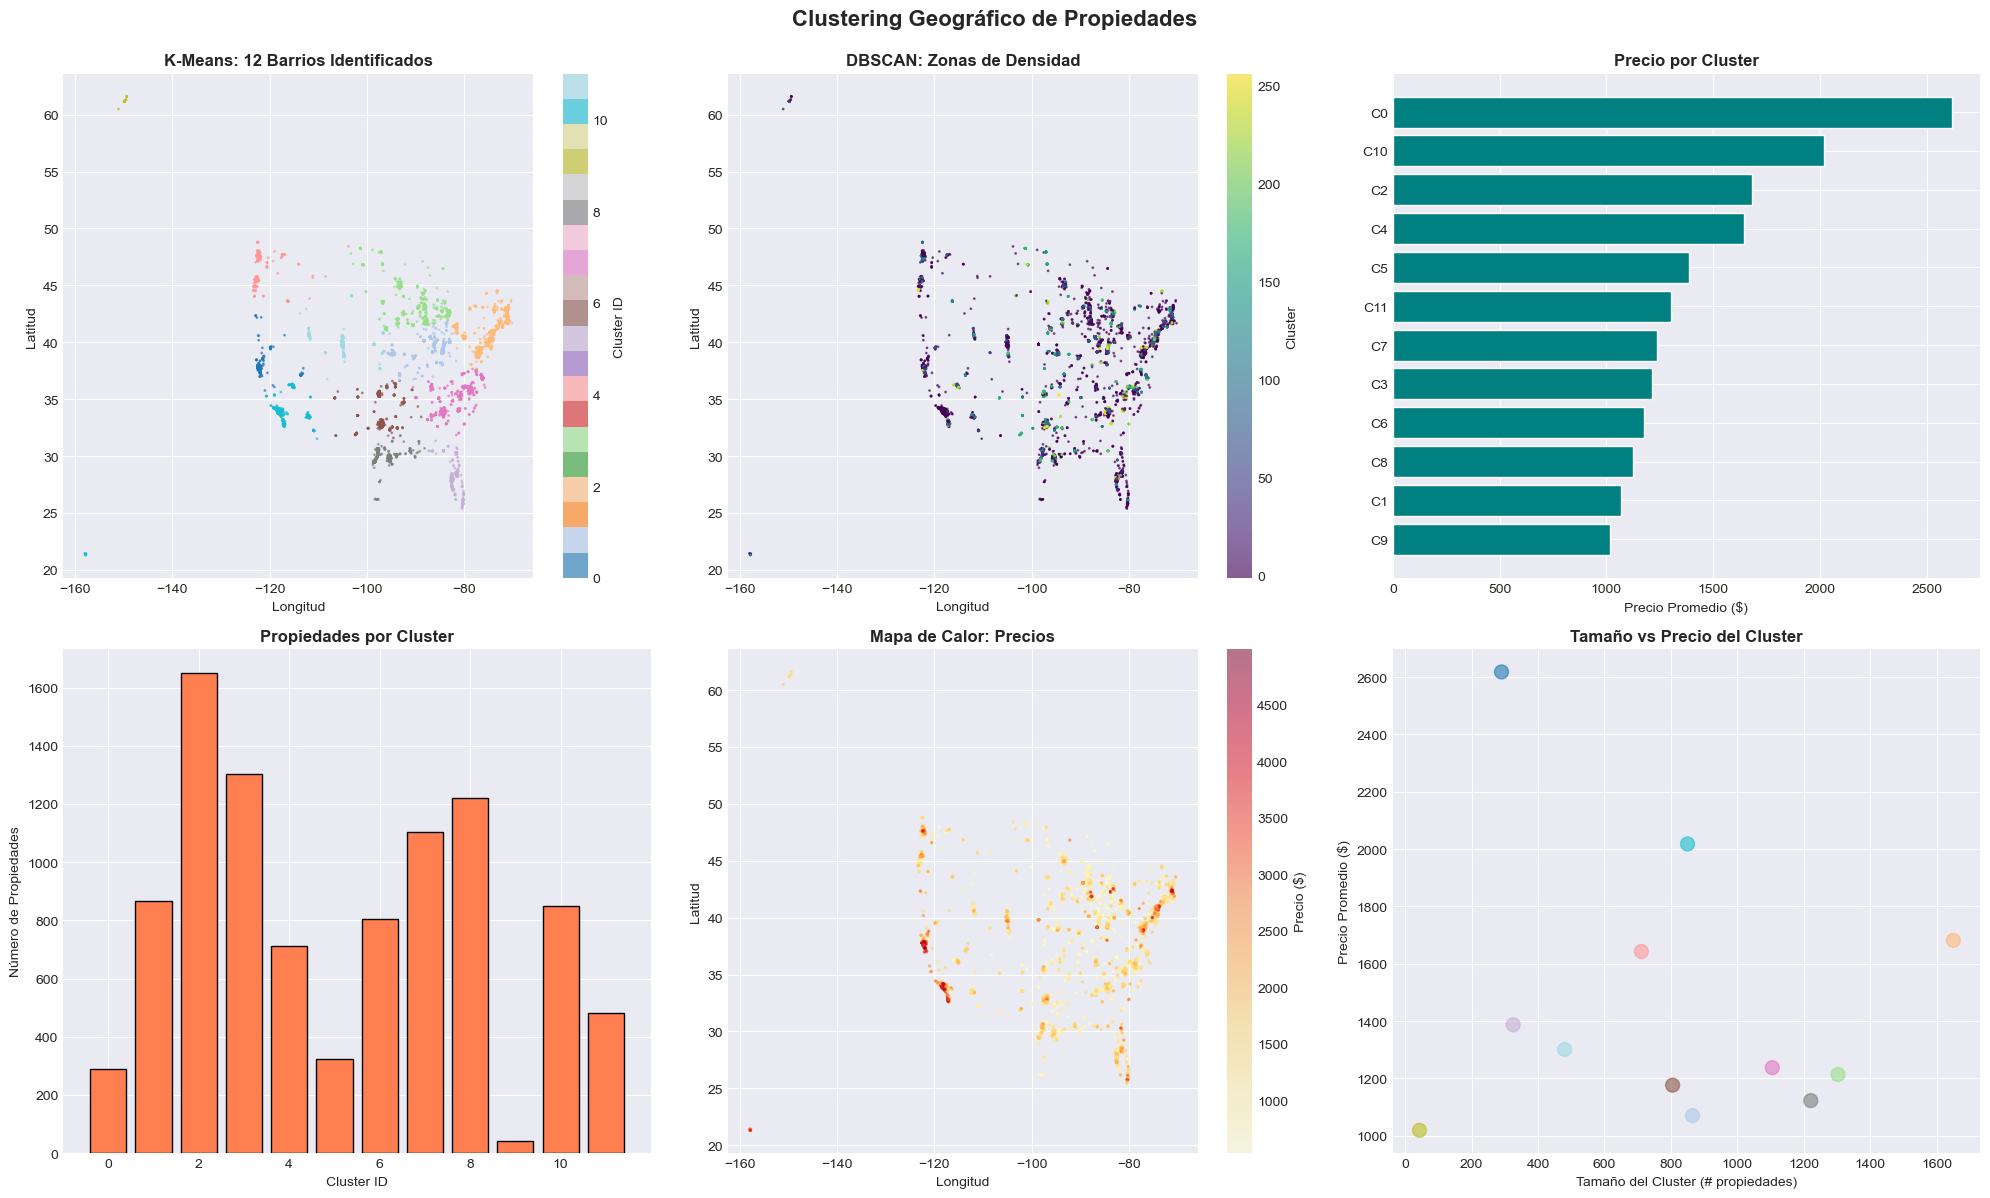

In [24]:
# Visualizaciones de clustering
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Clustering Geográfico de Propiedades', fontsize=16, fontweight='bold', y=0.995)

# 1. Mapa de clusters K-Means
scatter = axes[0, 0].scatter(df_clean['longitude'], df_clean['latitude'], 
                            c=df_clean['neighborhood_cluster'], 
                            cmap='tab20', s=1, alpha=0.6)
axes[0, 0].set_xlabel('Longitud')
axes[0, 0].set_ylabel('Latitud')
axes[0, 0].set_title('K-Means: 12 Barrios Identificados', fontweight='bold')
plt.colorbar(scatter, ax=axes[0, 0], label='Cluster ID')

# 2. Mapa DBSCAN
scatter = axes[0, 1].scatter(df_clean['longitude'], df_clean['latitude'], 
                            c=df_clean['density_cluster'], 
                            cmap='viridis', s=1, alpha=0.6)
axes[0, 1].set_xlabel('Longitud')
axes[0, 1].set_ylabel('Latitud')
axes[0, 1].set_title('DBSCAN: Zonas de Densidad', fontweight='bold')
plt.colorbar(scatter, ax=axes[0, 1], label='Cluster')

# 3. Precio promedio por cluster
cluster_prices = df_clean.groupby('neighborhood_cluster')['price'].mean().sort_values()
axes[0, 2].barh(range(len(cluster_prices)), cluster_prices.values, color='teal')
axes[0, 2].set_yticks(range(len(cluster_prices)))
axes[0, 2].set_yticklabels([f'C{i}' for i in cluster_prices.index])
axes[0, 2].set_xlabel('Precio Promedio ($)')
axes[0, 2].set_title('Precio por Cluster', fontweight='bold')

# 4. Distribución de propiedades
cluster_counts = df_clean['neighborhood_cluster'].value_counts().sort_index()
axes[1, 0].bar(cluster_counts.index, cluster_counts.values, color='coral', edgecolor='black')
axes[1, 0].set_xlabel('Cluster ID')
axes[1, 0].set_ylabel('Número de Propiedades')
axes[1, 0].set_title('Propiedades por Cluster', fontweight='bold')

# 5. Mapa de calor de precios
scatter = axes[1, 1].scatter(df_clean['longitude'], df_clean['latitude'], 
                            c=df_clean['price'], cmap='YlOrRd', s=2, alpha=0.5)
axes[1, 1].set_xlabel('Longitud')
axes[1, 1].set_ylabel('Latitud')
axes[1, 1].set_title('Mapa de Calor: Precios', fontweight='bold')
plt.colorbar(scatter, ax=axes[1, 1], label='Precio ($)')

# 6. Tamaño de cluster vs precio promedio
cluster_analysis = df_clean.groupby('neighborhood_cluster').agg({
    'price': 'mean',
    'cluster_size': 'first'
})
axes[1, 2].scatter(cluster_analysis['cluster_size'], cluster_analysis['price'], 
                  s=100, alpha=0.6, c=cluster_analysis.index, cmap='tab20')
axes[1, 2].set_xlabel('Tamaño del Cluster (# propiedades)')
axes[1, 2].set_ylabel('Precio Promedio ($)')
axes[1, 2].set_title('Tamaño vs Precio del Cluster', fontweight='bold')

plt.tight_layout()
plt.show()

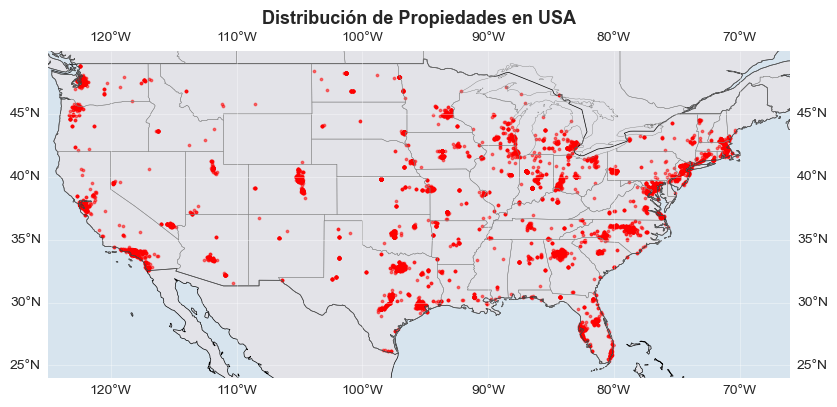

In [25]:
def mapa_con_cartopy(df_clean):

    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    fig = plt.figure(figsize=(24, 16))

    # Mapa 1: Distribución simple
    ax1 = plt.subplot(2, 3, 1, projection=ccrs.PlateCarree())
    ax1.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())


    ax1.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
    ax1.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.3)
    ax1.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax1.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax1.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='gray')

    # Graficar propiedades
    ax1.scatter(df_clean['longitude'], df_clean['latitude'],
               c='red', s=3, alpha=0.5, transform=ccrs.PlateCarree())
    ax1.set_title('Distribución de Propiedades en USA', fontsize=13, fontweight='bold')
    ax1.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)


    plt.tight_layout()
    plt.show()

mapa_con_cartopy(df_clean)

---
## 6. Análisis de Correlación

Analizamos las correlaciones entre variables numéricas y la variable objetivo (precio).

In [26]:
# Seleccionar variables numéricas relevantes
numerical_cols = [
    'price',              # Variable objetivo
    'bedrooms',           # Características físicas
    'bathrooms',
    'square_feet',
    'total_rooms',        # Variable derivada
    'pets_allowed_binary',
    'neighborhood_cluster',  # Clustering
    'cluster_size',
    'distance_to_centroid'
]

# Filtrar solo columnas que existen
numerical_cols = [col for col in numerical_cols if col in df_clean.columns]

# Calcular matriz de correlación
correlation_matrix = df_clean[numerical_cols].corr()

# Mostrar correlaciones con precio
print('CORRELACIONES CON PRECIO')
print('='*80)
price_corr = correlation_matrix['price'].sort_values(ascending=False)
for col, corr in price_corr.items():
    if col != 'price':
        bar = '█' * int(abs(corr) * 50)
        sign = '+' if corr > 0 else '-'
        print(f'{col:30s} {sign} {abs(corr):.3f} {bar}')

CORRELACIONES CON PRECIO
square_feet                    + 0.394 ███████████████████
bathrooms                      + 0.369 ██████████████████
total_rooms                    + 0.347 █████████████████
bedrooms                       + 0.288 ██████████████
pets_allowed_binary            - 0.031 █
neighborhood_cluster           - 0.048 ██
cluster_size                   - 0.055 ██
distance_to_centroid           - 0.147 ███████


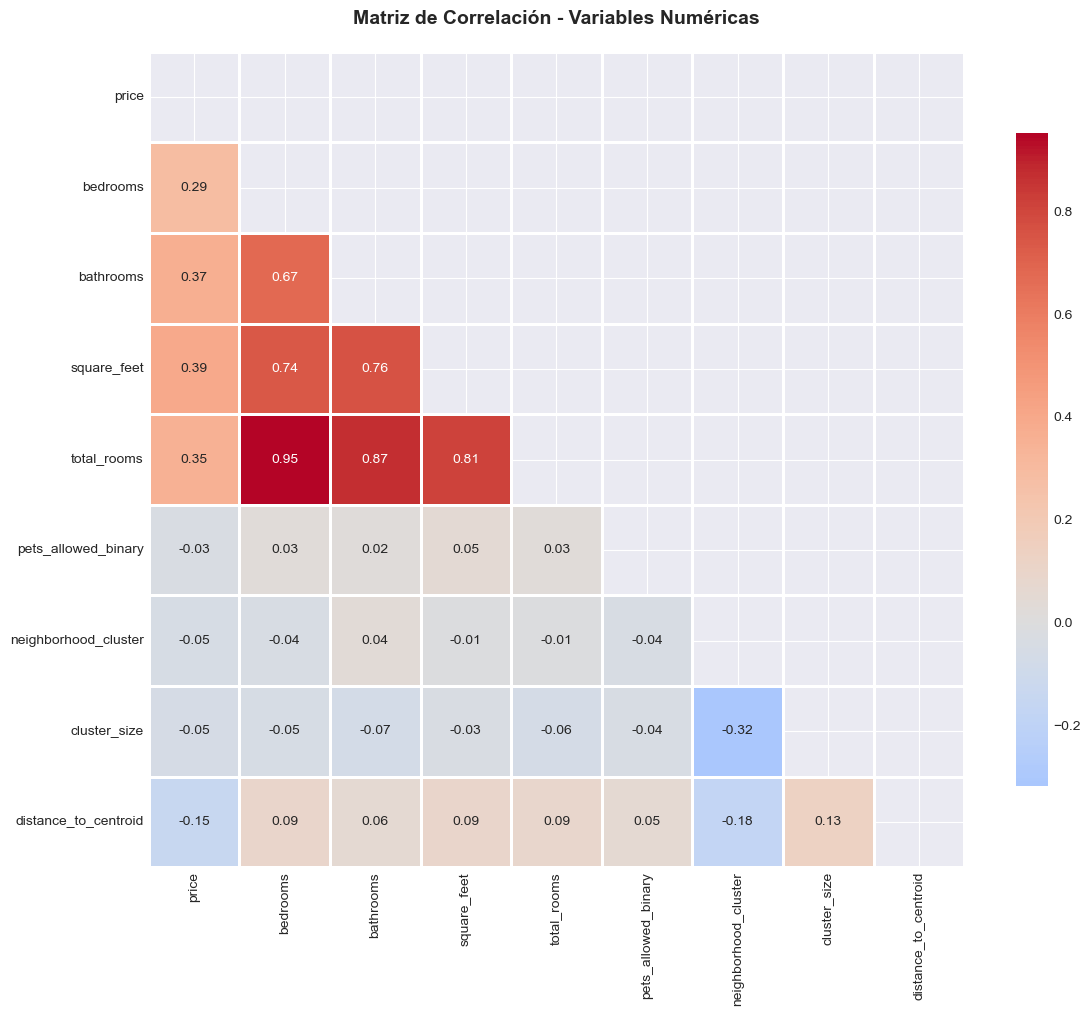

In [27]:
# Visualizar matriz de correlación
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, square=True, linewidths=1,
            cbar_kws={'shrink': 0.8})
plt.title('Matriz de Correlación - Variables Numéricas', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [28]:
# Verificación de colinealidad con VIF (Variance Inflation Factor)
# Según comentario profesor: "Tengan cuidado con la colinealidad de las variables"
from statsmodels.stats.outliers_influence import variance_inflation_factor

print('\nVERIFICACIÓN DE COLINEALIDAD (VIF)')
print('='*80)
print('VIF > 10: Alta colinealidad (problemático)')
print('VIF 5-10: Colinealidad moderada')
print('VIF < 5: Colinealidad aceptable\n')

# Variables a evaluar (excluyendo 'price' que es la variable objetivo)
vif_features = [col for col in numerical_cols if col != 'price' and col in df_clean.columns]

# Calcular VIF
vif_data = pd.DataFrame()
vif_data['Feature'] = vif_features

# Preparar datos para VIF
X_vif = df_clean[vif_features].values
vif_data['VIF'] = [variance_inflation_factor(X_vif, i) for i in range(len(vif_features))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print(vif_data.to_string(index=False))

# Advertencias
high_vif = vif_data[vif_data['VIF'] > 10]
if len(high_vif) > 0:
    print(f'\n⚠️  ADVERTENCIA: {len(high_vif)} variable(s) con VIF > 10:')
    for _, row in high_vif.iterrows():
        print(f'     • {row["Feature"]}: VIF = {row["VIF"]:.2f}')
    print('\n   Recomendación: Considerar eliminar o combinar estas variables')
else:
    print('\n✓ No se detectaron problemas graves de colinealidad')


VERIFICACIÓN DE COLINEALIDAD (VIF)
VIF > 10: Alta colinealidad (problemático)
VIF 5-10: Colinealidad moderada
VIF < 5: Colinealidad aceptable

             Feature       VIF
            bedrooms       inf
           bathrooms       inf
         total_rooms       inf
         square_feet 18.392000
        cluster_size  4.836778
neighborhood_cluster  2.842198
distance_to_centroid  2.607009
 pets_allowed_binary  2.286933

⚠️  ADVERTENCIA: 4 variable(s) con VIF > 10:
     • bedrooms: VIF = inf
     • bathrooms: VIF = inf
     • total_rooms: VIF = inf
     • square_feet: VIF = 18.39

   Recomendación: Considerar eliminar o combinar estas variables


---
## 7. Construcción de Modelo Predictivo

Implementaremos varios modelos de regresión y los compararemos para seleccionar el mejor.

**Modelos a implementar:**
- Regresión Lineal (baseline)
- Random Forest Regressor
- Gradient Boosting Regressor
- **K-Nearest Neighbors (KNN)** ← Sugerido por profesor

In [29]:
# Importar modelos y métricas
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print('='*80)
print('PREPARACIÓN DE DATOS PARA MODELADO')
print('='*80)

# 1. Codificación de variables categóricas
print('\n1. CODIFICACIÓN DE VARIABLES CATEGÓRICAS')
print('-'*80)

df_model = df_clean.copy()

# Label Encoding para state y cityname
le_state = LabelEncoder()
le_city = LabelEncoder()
le_area = LabelEncoder()

# Rellenar nulos antes de codificar
df_model['state'] = df_model['state'].fillna('Unknown')
df_model['cityname'] = df_model['cityname'].fillna('Unknown')

df_model['state_encoded'] = le_state.fit_transform(df_model['state'])
df_model['city_encoded'] = le_city.fit_transform(df_model['cityname'])
df_model['area_type_encoded'] = le_area.fit_transform(df_model['area_type'])

print(f'✓ state_encoded: {df_model["state_encoded"].nunique()} estados')
print(f'✓ city_encoded: {df_model["city_encoded"].nunique()} ciudades')
print(f'✓ area_type_encoded: 3 tipos (Urbano/Suburbio/Rural)')

print(f'\nDataset codificado: {df_model.shape}')

PREPARACIÓN DE DATOS PARA MODELADO

1. CODIFICACIÓN DE VARIABLES CATEGÓRICAS
--------------------------------------------------------------------------------
✓ state_encoded: 52 estados
✓ city_encoded: 1525 ciudades
✓ area_type_encoded: 3 tipos (Urbano/Suburbio/Rural)

Dataset codificado: (9648, 33)


In [30]:
# 2. Selección de features
print('\n2. SELECCIÓN DE FEATURES')
print('-'*80)

# Features para el modelo (evitando colinealidad alta)
features_to_use = [
    # Características físicas
    'bedrooms', 'bathrooms', 'square_feet', 'total_rooms',
    # Ubicación
    'state_encoded', 'city_encoded', 'latitude', 'longitude',
    # Tipo de área
    'area_type_encoded',
    # Clustering geográfico
    'neighborhood_cluster', 'cluster_size', 'distance_to_centroid',
    # Otras
    'pets_allowed_binary'
]

# Verificar que existan
features_to_use = [f for f in features_to_use if f in df_model.columns]

X = df_model[features_to_use]
y = df_model['price']

print(f'✓ {len(features_to_use)} features seleccionadas')
print(f'✓ Variable objetivo: price')
print(f'\nFeatures: {features_to_use}')


2. SELECCIÓN DE FEATURES
--------------------------------------------------------------------------------
✓ 13 features seleccionadas
✓ Variable objetivo: price

Features: ['bedrooms', 'bathrooms', 'square_feet', 'total_rooms', 'state_encoded', 'city_encoded', 'latitude', 'longitude', 'area_type_encoded', 'neighborhood_cluster', 'cluster_size', 'distance_to_centroid', 'pets_allowed_binary']


In [31]:
# 3. División train/test (80/20)
print('\n3. DIVISIÓN TRAIN/TEST')
print('-'*80)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train set: {X_train.shape[0]:,} muestras ({(len(X_train)/len(X)*100):.1f}%)')
print(f'Test set:  {X_test.shape[0]:,} muestras ({(len(X_test)/len(X)*100):.1f}%)')

# 4. Normalización de features
print('\n4. NORMALIZACIÓN')
print('-'*80)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'✓ Features normalizadas con StandardScaler')
print(f'✓ Media ≈ 0, Desviación estándar ≈ 1')

print('\n' + '='*80)
print('DATOS LISTOS PARA MODELADO')
print('='*80)


3. DIVISIÓN TRAIN/TEST
--------------------------------------------------------------------------------
Train set: 7,718 muestras (80.0%)
Test set:  1,930 muestras (20.0%)

4. NORMALIZACIÓN
--------------------------------------------------------------------------------
✓ Features normalizadas con StandardScaler
✓ Media ≈ 0, Desviación estándar ≈ 1

DATOS LISTOS PARA MODELADO


In [32]:
# ENTRENAMIENTO DE MODELOS
print('\n' + '='*80)
print('ENTRENAMIENTO DE MODELOS')
print('='*80)

# Diccionario para almacenar modelos y resultados
models = {}
results = {}

# 1. REGRESIÓN LINEAL (Baseline)
print('\n1. REGRESIÓN LINEAL (Baseline)')
print('-'*80)
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr_train = lr.predict(X_train_scaled)
y_pred_lr_test = lr.predict(X_test_scaled)

rmse_lr_train = np.sqrt(mean_squared_error(y_train, y_pred_lr_train))
rmse_lr_test = np.sqrt(mean_squared_error(y_test, y_pred_lr_test))
mae_lr = mean_absolute_error(y_test, y_pred_lr_test)
r2_lr = r2_score(y_test, y_pred_lr_test)

models['Linear Regression'] = lr
results['Linear Regression'] = {
    'RMSE_train': rmse_lr_train, 'RMSE_test': rmse_lr_test,
    'MAE': mae_lr, 'R2': r2_lr, 'predictions': y_pred_lr_test
}

print(f'RMSE Train: ${rmse_lr_train:,.2f}')
print(f'RMSE Test:  ${rmse_lr_test:,.2f}')
print(f'MAE:        ${mae_lr:,.2f}')
print(f'R²:         {r2_lr:.4f}')

# 2. RANDOM FOREST
print('\n2. RANDOM FOREST REGRESSOR')
print('-'*80)
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, max_depth=20)
rf.fit(X_train, y_train)

y_pred_rf_train = rf.predict(X_train)
y_pred_rf_test = rf.predict(X_test)

rmse_rf_train = np.sqrt(mean_squared_error(y_train, y_pred_rf_train))
rmse_rf_test = np.sqrt(mean_squared_error(y_test, y_pred_rf_test))
mae_rf = mean_absolute_error(y_test, y_pred_rf_test)
r2_rf = r2_score(y_test, y_pred_rf_test)

models['Random Forest'] = rf
results['Random Forest'] = {
    'RMSE_train': rmse_rf_train, 'RMSE_test': rmse_rf_test,
    'MAE': mae_rf, 'R2': r2_rf, 'predictions': y_pred_rf_test
}

print(f'RMSE Train: ${rmse_rf_train:,.2f}')
print(f'RMSE Test:  ${rmse_rf_test:,.2f}')
print(f'MAE:        ${mae_rf:,.2f}')
print(f'R²:         {r2_rf:.4f}')

# 3. GRADIENT BOOSTING
print('\n3. GRADIENT BOOSTING REGRESSOR')
print('-'*80)
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
gb.fit(X_train, y_train)

y_pred_gb_train = gb.predict(X_train)
y_pred_gb_test = gb.predict(X_test)

rmse_gb_train = np.sqrt(mean_squared_error(y_train, y_pred_gb_train))
rmse_gb_test = np.sqrt(mean_squared_error(y_test, y_pred_gb_test))
mae_gb = mean_absolute_error(y_test, y_pred_gb_test)
r2_gb = r2_score(y_test, y_pred_gb_test)

models['Gradient Boosting'] = gb
results['Gradient Boosting'] = {
    'RMSE_train': rmse_gb_train, 'RMSE_test': rmse_gb_test,
    'MAE': mae_gb, 'R2': r2_gb, 'predictions': y_pred_gb_test
}

print(f'RMSE Train: ${rmse_gb_train:,.2f}')
print(f'RMSE Test:  ${rmse_gb_test:,.2f}')
print(f'MAE:        ${mae_gb:,.2f}')
print(f'R²:         {r2_gb:.4f}')

# 4. K-NEAREST NEIGHBORS (Sugerido por profesor)
print('\n4. K-NEAREST NEIGHBORS (KNN) ← Sugerido por profesor')
print('-'*80)
knn = KNeighborsRegressor(n_neighbors=5, weights='distance')
knn.fit(X_train_scaled, y_train)

y_pred_knn_train = knn.predict(X_train_scaled)
y_pred_knn_test = knn.predict(X_test_scaled)

rmse_knn_train = np.sqrt(mean_squared_error(y_train, y_pred_knn_train))
rmse_knn_test = np.sqrt(mean_squared_error(y_test, y_pred_knn_test))
mae_knn = mean_absolute_error(y_test, y_pred_knn_test)
r2_knn = r2_score(y_test, y_pred_knn_test)

models['KNN'] = knn
results['KNN'] = {
    'RMSE_train': rmse_knn_train, 'RMSE_test': rmse_knn_test,
    'MAE': mae_knn, 'R2': r2_knn, 'predictions': y_pred_knn_test
}

print(f'RMSE Train: ${rmse_knn_train:,.2f}')
print(f'RMSE Test:  ${rmse_knn_test:,.2f}')
print(f'MAE:        ${mae_knn:,.2f}')
print(f'R²:         {r2_knn:.4f}')

print('\n' + '='*80)
print('✓ TODOS LOS MODELOS ENTRENADOS')
print('='*80)


ENTRENAMIENTO DE MODELOS

1. REGRESIÓN LINEAL (Baseline)
--------------------------------------------------------------------------------
RMSE Train: $535.95
RMSE Test:  $562.20
MAE:        $398.72
R²:         0.3669

2. RANDOM FOREST REGRESSOR
--------------------------------------------------------------------------------
RMSE Train: $135.65
RMSE Test:  $340.52
MAE:        $226.81
R²:         0.7677

3. GRADIENT BOOSTING REGRESSOR
--------------------------------------------------------------------------------
RMSE Train: $267.86
RMSE Test:  $347.34
MAE:        $239.34
R²:         0.7583

4. K-NEAREST NEIGHBORS (KNN) ← Sugerido por profesor
--------------------------------------------------------------------------------
RMSE Train: $43.08
RMSE Test:  $394.92
MAE:        $258.46
R²:         0.6876

✓ TODOS LOS MODELOS ENTRENADOS


In [33]:
# VALIDACIÓN CRUZADA
print('\n' + '='*80)
print('VALIDACIÓN CRUZADA (5-Fold)')
print('='*80)

cv_results = {}

# Linear Regression
cv_lr = cross_val_score(lr, X_train_scaled, y_train, cv=5, 
                        scoring='neg_root_mean_squared_error', n_jobs=-1)
cv_results['Linear Regression'] = -cv_lr.mean()
print(f'Linear Regression: RMSE CV = ${-cv_lr.mean():,.2f} (+/- ${cv_lr.std():,.2f})')

# Random Forest
cv_rf = cross_val_score(rf, X_train, y_train, cv=5, 
                        scoring='neg_root_mean_squared_error', n_jobs=-1)
cv_results['Random Forest'] = -cv_rf.mean()
print(f'Random Forest:     RMSE CV = ${-cv_rf.mean():,.2f} (+/- ${cv_rf.std():,.2f})')

# Gradient Boosting
cv_gb = cross_val_score(gb, X_train, y_train, cv=5, 
                        scoring='neg_root_mean_squared_error', n_jobs=-1)
cv_results['Gradient Boosting'] = -cv_gb.mean()
print(f'Gradient Boosting: RMSE CV = ${-cv_gb.mean():,.2f} (+/- ${cv_gb.std():,.2f})')

# KNN
cv_knn = cross_val_score(knn, X_train_scaled, y_train, cv=5, 
                         scoring='neg_root_mean_squared_error', n_jobs=-1)
cv_results['KNN'] = -cv_knn.mean()
print(f'KNN:               RMSE CV = ${-cv_knn.mean():,.2f} (+/- ${cv_knn.std():,.2f})')


VALIDACIÓN CRUZADA (5-Fold)
Linear Regression: RMSE CV = $537.10 (+/- $7.03)
Random Forest:     RMSE CV = $340.67 (+/- $8.66)
Gradient Boosting: RMSE CV = $334.70 (+/- $9.44)
KNN:               RMSE CV = $407.85 (+/- $4.72)


In [34]:
# OPTIMIZACIÓN DE HIPERPARÁMETROS
print('\n' + '='*80)
print('OPTIMIZACIÓN DE HIPERPARÁMETROS (GridSearchCV)')
print('='*80)

# Optimizar KNN (sugerido por profesor)
print('\n1. Optimizando KNN...')
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 10],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]  # 1=manhattan, 2=euclidean
}
grid_knn = GridSearchCV(KNeighborsRegressor(), param_grid_knn, cv=3, 
                        scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=0)
grid_knn.fit(X_train_scaled, y_train)

print(f'   Mejores parámetros: {grid_knn.best_params_}')
print(f'   Mejor RMSE CV: ${-grid_knn.best_score_:,.2f}')

knn_opt = grid_knn.best_estimator_
y_pred_knn_opt = knn_opt.predict(X_test_scaled)

results['KNN Optimizado'] = {
    'RMSE_train': np.sqrt(mean_squared_error(y_train, knn_opt.predict(X_train_scaled))),
    'RMSE_test': np.sqrt(mean_squared_error(y_test, y_pred_knn_opt)),
    'MAE': mean_absolute_error(y_test, y_pred_knn_opt),
    'R2': r2_score(y_test, y_pred_knn_opt),
    'predictions': y_pred_knn_opt
}
models['KNN Optimizado'] = knn_opt

# Optimizar Random Forest
print('\n2. Optimizando Random Forest...')
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [15, 20, 25],
    'min_samples_split': [2, 5]
}
grid_rf = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1), 
                       param_grid_rf, cv=3, scoring='neg_root_mean_squared_error', 
                       n_jobs=-1, verbose=0)
grid_rf.fit(X_train, y_train)

print(f'   Mejores parámetros: {grid_rf.best_params_}')
print(f'   Mejor RMSE CV: ${-grid_rf.best_score_:,.2f}')

rf_opt = grid_rf.best_estimator_
y_pred_rf_opt = rf_opt.predict(X_test)

results['Random Forest Optimizado'] = {
    'RMSE_train': np.sqrt(mean_squared_error(y_train, rf_opt.predict(X_train))),
    'RMSE_test': np.sqrt(mean_squared_error(y_test, y_pred_rf_opt)),
    'MAE': mean_absolute_error(y_test, y_pred_rf_opt),
    'R2': r2_score(y_test, y_pred_rf_opt),
    'predictions': y_pred_rf_opt
}
models['Random Forest Optimizado'] = rf_opt

print('\n✓ Optimización completada')


OPTIMIZACIÓN DE HIPERPARÁMETROS (GridSearchCV)

1. Optimizando KNN...
   Mejores parámetros: {'n_neighbors': 7, 'p': 1, 'weights': 'distance'}
   Mejor RMSE CV: $394.10

2. Optimizando Random Forest...
   Mejores parámetros: {'max_depth': 15, 'min_samples_split': 5, 'n_estimators': 200}
   Mejor RMSE CV: $342.86

✓ Optimización completada


---
## 8. Resultados y Análisis

Análisis detallado del rendimiento de los modelos y visualizaciones de resultados.

In [35]:
# COMPARACIÓN DE MODELOS
print('='*80)
print('COMPARACIÓN DE RENDIMIENTO DE MODELOS')
print('='*80)

# Crear tabla comparativa
comparison_df = pd.DataFrame({
    'Modelo': list(results.keys()),
    'RMSE Train': [results[m]['RMSE_train'] for m in results.keys()],
    'RMSE Test': [results[m]['RMSE_test'] for m in results.keys()],
    'MAE': [results[m]['MAE'] for m in results.keys()],
    'R²': [results[m]['R2'] for m in results.keys()]
})

# Ordenar por RMSE Test (menor es mejor)
comparison_df = comparison_df.sort_values('RMSE Test')
comparison_df = comparison_df.round(2)

print('\nTABLA COMPARATIVA:')
print(comparison_df.to_string(index=False))

# Identificar mejor modelo
best_model_name = comparison_df.iloc[0]['Modelo']
best_rmse = comparison_df.iloc[0]['RMSE Test']
best_mae = comparison_df.iloc[0]['MAE']
best_r2 = comparison_df.iloc[0]['R²']

print(f'\n{"="*80}')
print(f'🏆 MEJOR MODELO: {best_model_name}')
print(f'{"="*80}')
print(f'   RMSE Test: ${best_rmse:,.2f}')
print(f'   MAE:       ${best_mae:,.2f}')
print(f'   R²:        {best_r2:.4f}')
print(f'   Error %:   {(best_mae / y_test.mean() * 100):.2f}%')
print(f'{"="*80}')

COMPARACIÓN DE RENDIMIENTO DE MODELOS

TABLA COMPARATIVA:
                  Modelo  RMSE Train  RMSE Test    MAE   R²
Random Forest Optimizado      187.61     339.18 228.08 0.77
           Random Forest      135.65     340.52 226.81 0.77
       Gradient Boosting      267.86     347.34 239.34 0.76
          KNN Optimizado       42.91     372.92 246.96 0.72
                     KNN       43.08     394.92 258.46 0.69
       Linear Regression      535.95     562.20 398.72 0.37

🏆 MEJOR MODELO: Random Forest Optimizado
   RMSE Test: $339.18
   MAE:       $228.08
   R²:        0.7700
   Error %:   15.91%


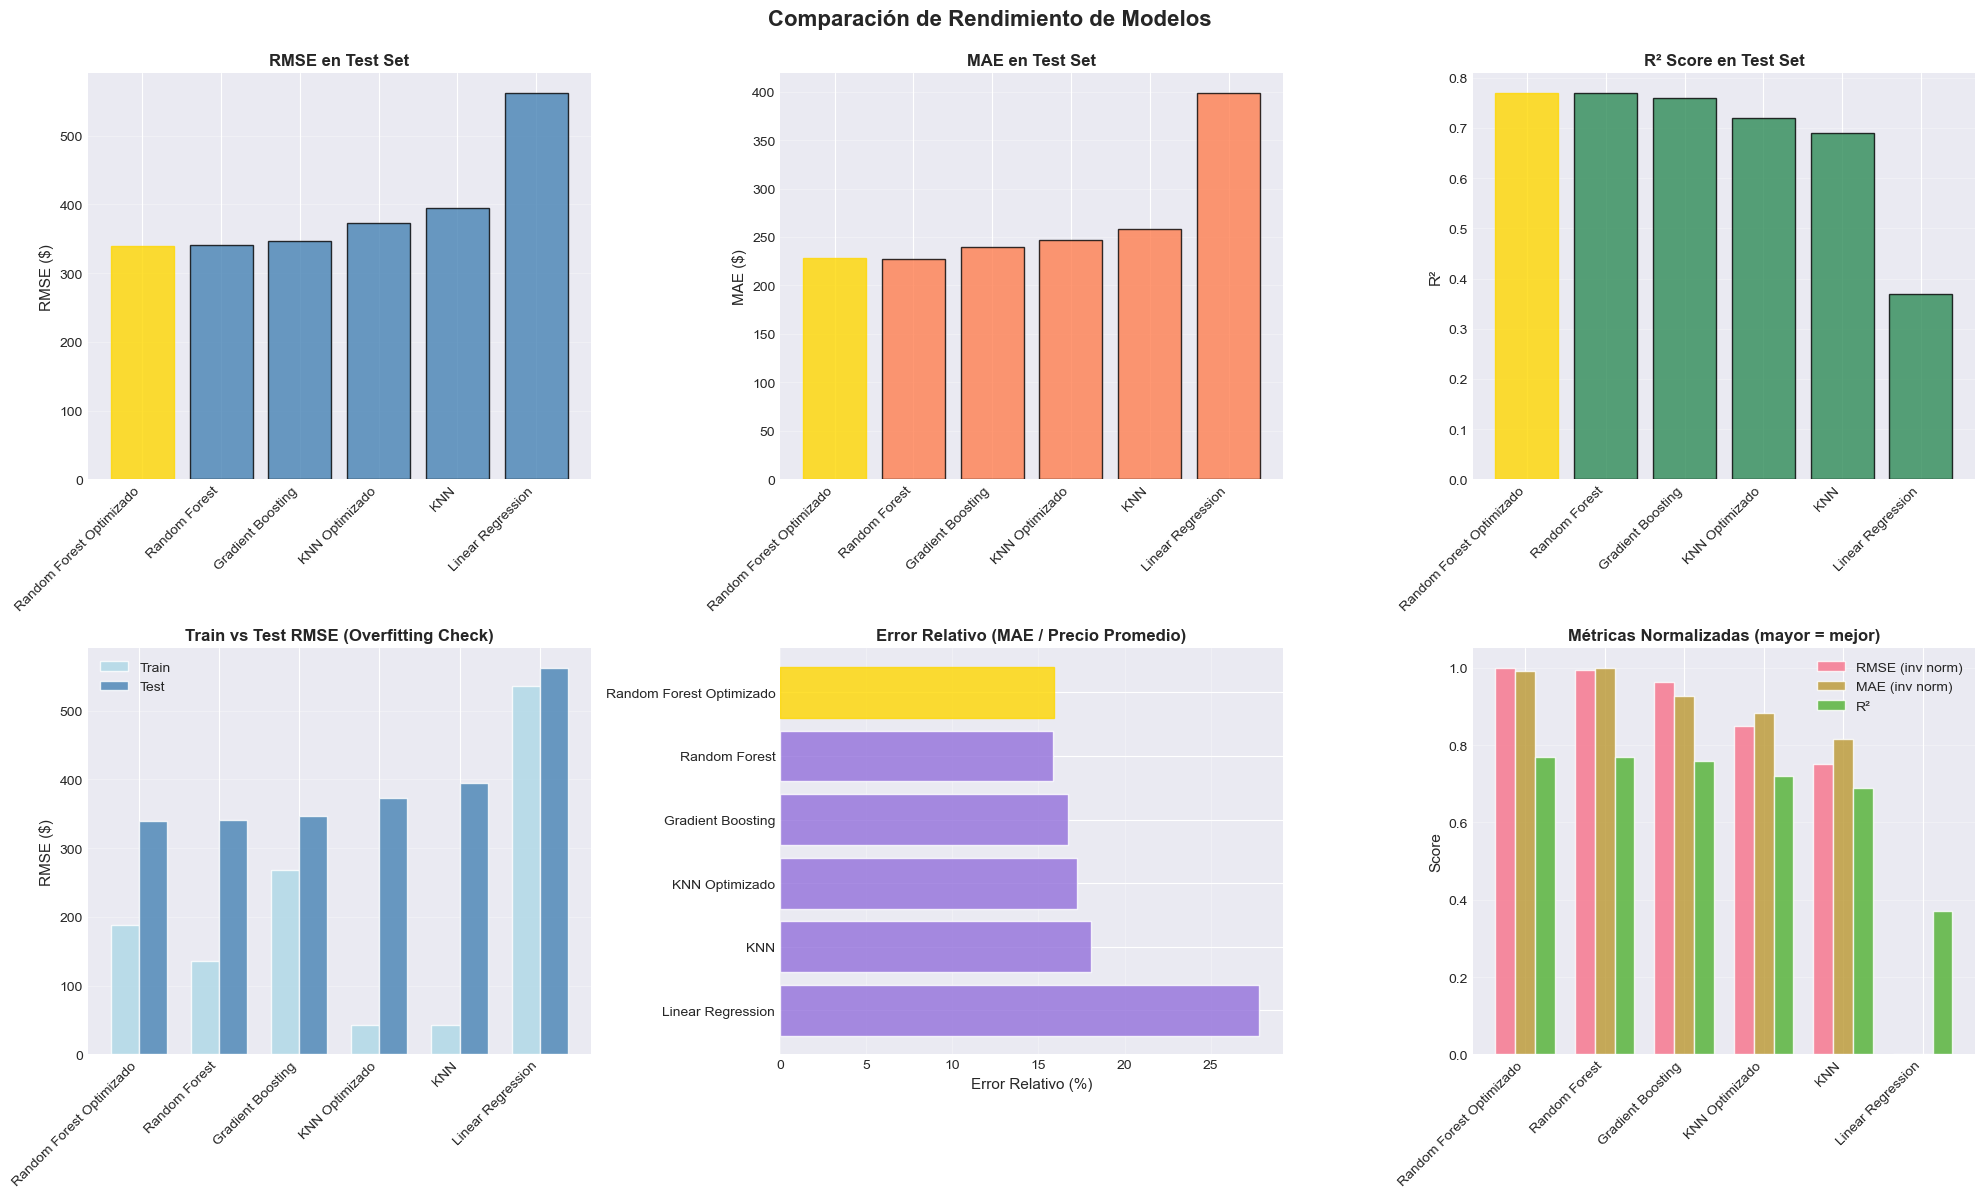

In [36]:
# VISUALIZACIONES COMPARATIVAS DE MODELOS
fig = plt.figure(figsize=(20, 12))
fig.suptitle('Comparación de Rendimiento de Modelos', fontsize=16, fontweight='bold', y=0.995)

# 1. Comparación RMSE
ax1 = plt.subplot(2, 3, 1)
x_pos = np.arange(len(comparison_df))
bars = ax1.bar(x_pos, comparison_df['RMSE Test'], color='steelblue', alpha=0.8, edgecolor='black')
# Resaltar el mejor
bars[0].set_color('gold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(comparison_df['Modelo'], rotation=45, ha='right')
ax1.set_ylabel('RMSE ($)', fontsize=11)
ax1.set_title('RMSE en Test Set', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# 2. Comparación MAE
ax2 = plt.subplot(2, 3, 2)
bars = ax2.bar(x_pos, comparison_df['MAE'], color='coral', alpha=0.8, edgecolor='black')
bars[0].set_color('gold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(comparison_df['Modelo'], rotation=45, ha='right')
ax2.set_ylabel('MAE ($)', fontsize=11)
ax2.set_title('MAE en Test Set', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# 3. Comparación R²
ax3 = plt.subplot(2, 3, 3)
bars = ax3.bar(x_pos, comparison_df['R²'], color='seagreen', alpha=0.8, edgecolor='black')
bars[0].set_color('gold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(comparison_df['Modelo'], rotation=45, ha='right')
ax3.set_ylabel('R²', fontsize=11)
ax3.set_title('R² Score en Test Set', fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# 4. Train vs Test RMSE (Overfitting check)
ax4 = plt.subplot(2, 3, 4)
width = 0.35
x_pos = np.arange(len(comparison_df))
ax4.bar(x_pos - width/2, comparison_df['RMSE Train'], width, label='Train', alpha=0.8, color='lightblue')
ax4.bar(x_pos + width/2, comparison_df['RMSE Test'], width, label='Test', alpha=0.8, color='steelblue')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(comparison_df['Modelo'], rotation=45, ha='right')
ax4.set_ylabel('RMSE ($)', fontsize=11)
ax4.set_title('Train vs Test RMSE (Overfitting Check)', fontweight='bold')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

# 5. Error Relativo (%)
ax5 = plt.subplot(2, 3, 5)
error_pct = (comparison_df['MAE'] / y_test.mean()) * 100
bars = ax5.barh(range(len(comparison_df)), error_pct, color='mediumpurple', alpha=0.8)
bars[0].set_color('gold')
ax5.set_yticks(range(len(comparison_df)))
ax5.set_yticklabels(comparison_df['Modelo'])
ax5.set_xlabel('Error Relativo (%)', fontsize=11)
ax5.set_title('Error Relativo (MAE / Precio Promedio)', fontweight='bold')
ax5.grid(axis='x', alpha=0.3)
ax5.invert_yaxis()

# 6. Métricas normalizadas
ax6 = plt.subplot(2, 3, 6)
from sklearn.preprocessing import MinMaxScaler
scaler_viz = MinMaxScaler()
rmse_norm = 1 - scaler_viz.fit_transform(comparison_df[['RMSE Test']].values).flatten()
mae_norm = 1 - scaler_viz.fit_transform(comparison_df[['MAE']].values).flatten()
r2_norm = comparison_df['R²'].values

width = 0.25
x_pos = np.arange(len(comparison_df))
ax6.bar(x_pos - width, rmse_norm, width, label='RMSE (inv norm)', alpha=0.8)
ax6.bar(x_pos, mae_norm, width, label='MAE (inv norm)', alpha=0.8)
ax6.bar(x_pos + width, r2_norm, width, label='R²', alpha=0.8)
ax6.set_xticks(x_pos)
ax6.set_xticklabels(comparison_df['Modelo'], rotation=45, ha='right')
ax6.set_ylabel('Score', fontsize=11)
ax6.set_title('Métricas Normalizadas (mayor = mejor)', fontweight='bold')
ax6.legend()
ax6.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

ANÁLISIS DETALLADO: Random Forest Optimizado

Estadísticas de Residuos:
  Media:       $-3.34 (ideal: $0)
  Desv. Est.:  $339.25
  Mínimo:      $-1380.53
  Máximo:      $2507.49


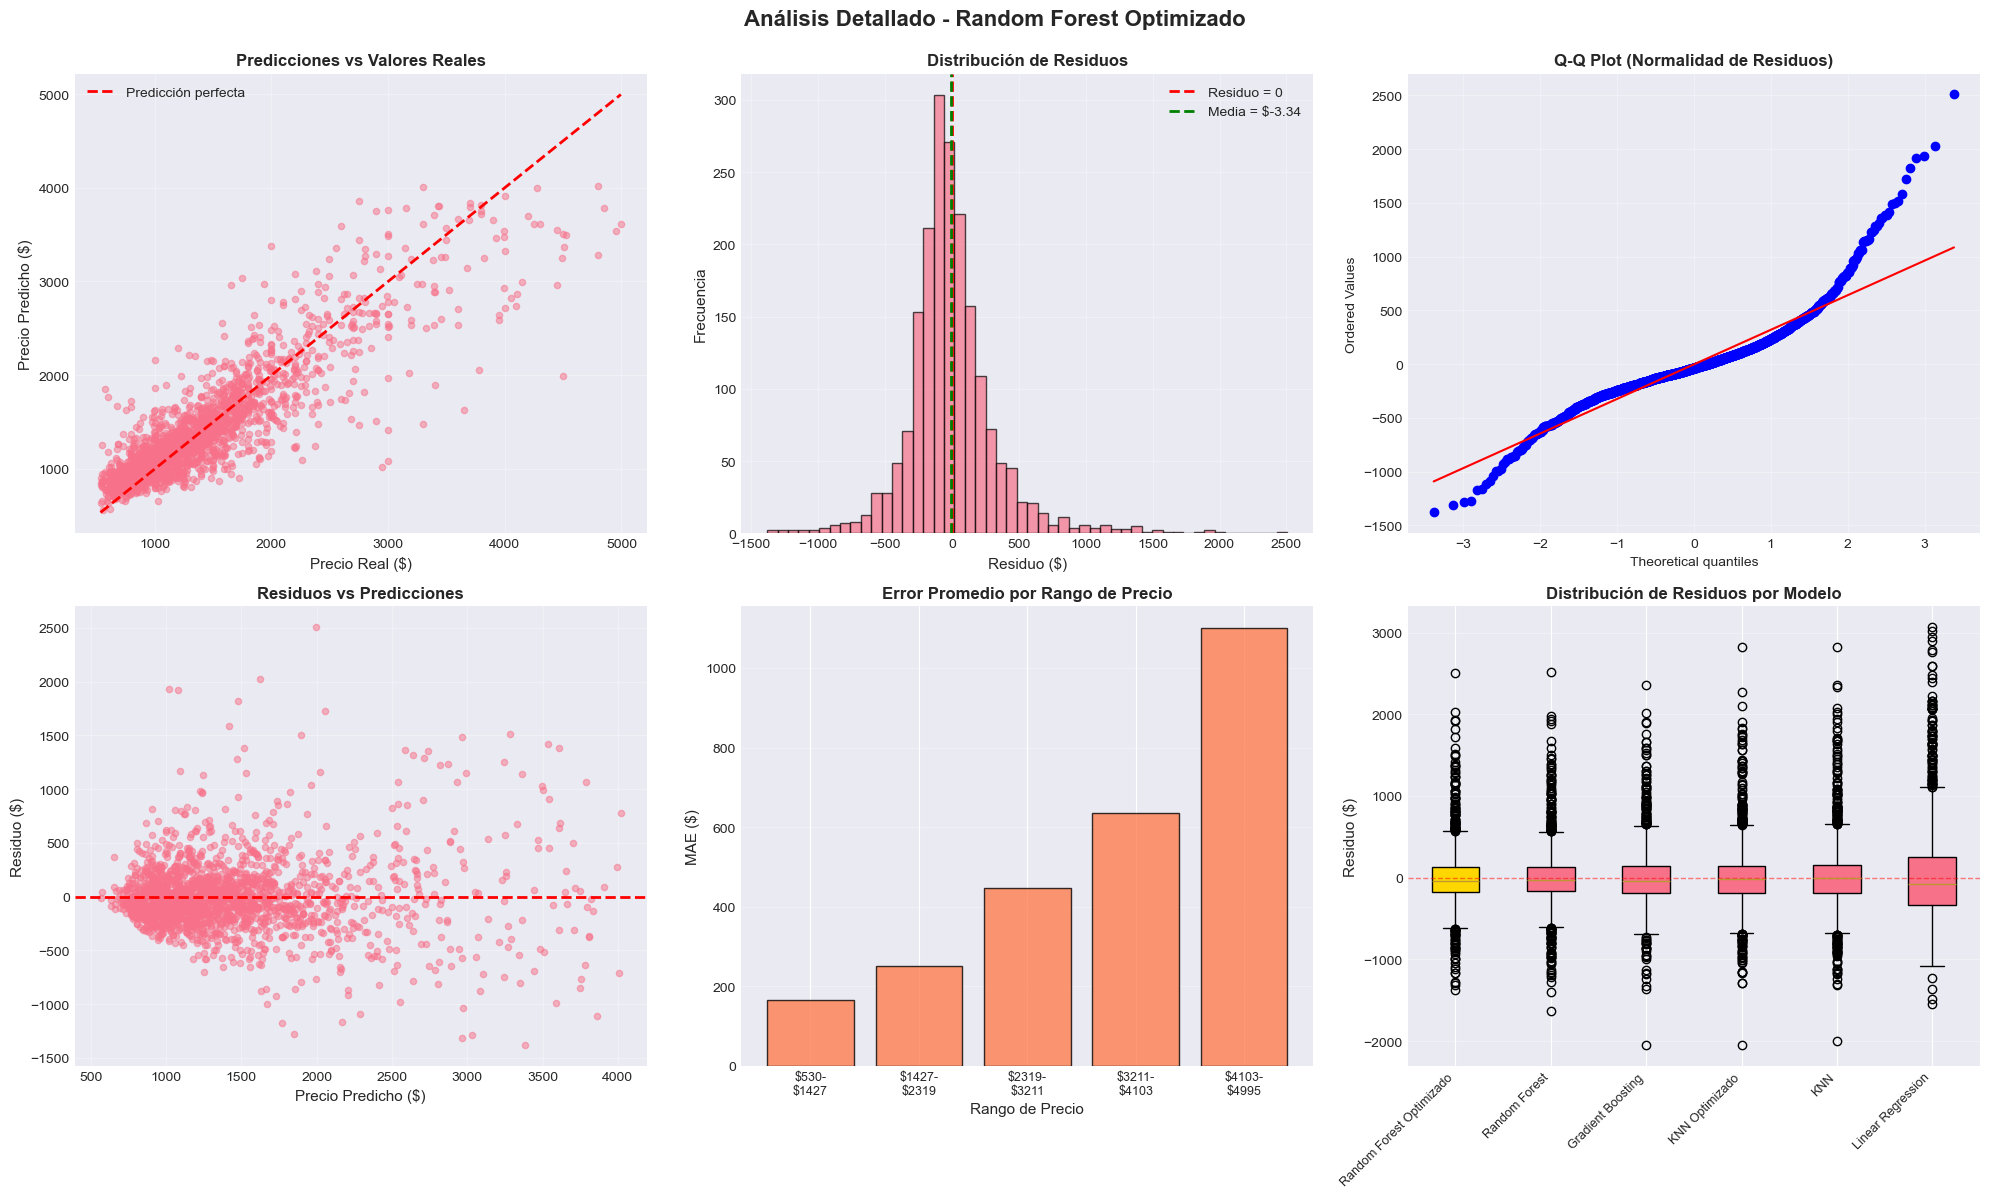

In [37]:
# ANÁLISIS DETALLADO DEL MEJOR MODELO
print('='*80)
print(f'ANÁLISIS DETALLADO: {best_model_name}')
print('='*80)

# Obtener predicciones del mejor modelo
y_pred_best = results[best_model_name]['predictions']
residuos = y_test - y_pred_best

print(f'\nEstadísticas de Residuos:')
print(f'  Media:       ${residuos.mean():.2f} (ideal: $0)')
print(f'  Desv. Est.:  ${residuos.std():.2f}')
print(f'  Mínimo:      ${residuos.min():.2f}')
print(f'  Máximo:      ${residuos.max():.2f}')

# Visualizaciones del mejor modelo
fig = plt.figure(figsize=(20, 12))
fig.suptitle(f'Análisis Detallado - {best_model_name}', fontsize=16, fontweight='bold', y=0.995)

# 1. Predicciones vs Valores Reales
ax1 = plt.subplot(2, 3, 1)
ax1.scatter(y_test, y_pred_best, alpha=0.5, s=20)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Predicción perfecta')
ax1.set_xlabel('Precio Real ($)', fontsize=11)
ax1.set_ylabel('Precio Predicho ($)', fontsize=11)
ax1.set_title('Predicciones vs Valores Reales', fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# 2. Distribución de Residuos
ax2 = plt.subplot(2, 3, 2)
ax2.hist(residuos, bins=50, edgecolor='black', alpha=0.7)
ax2.axvline(0, color='red', linestyle='--', linewidth=2, label='Residuo = 0')
ax2.axvline(residuos.mean(), color='green', linestyle='--', linewidth=2, 
           label=f'Media = ${residuos.mean():.2f}')
ax2.set_xlabel('Residuo ($)', fontsize=11)
ax2.set_ylabel('Frecuencia', fontsize=11)
ax2.set_title('Distribución de Residuos', fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

# 3. Q-Q Plot (normalidad)
ax3 = plt.subplot(2, 3, 3)
from scipy import stats
stats.probplot(residuos, dist="norm", plot=ax3)
ax3.set_title('Q-Q Plot (Normalidad de Residuos)', fontweight='bold')
ax3.grid(alpha=0.3)

# 4. Residuos vs Predicciones
ax4 = plt.subplot(2, 3, 4)
ax4.scatter(y_pred_best, residuos, alpha=0.5, s=20)
ax4.axhline(0, color='red', linestyle='--', linewidth=2)
ax4.set_xlabel('Precio Predicho ($)', fontsize=11)
ax4.set_ylabel('Residuo ($)', fontsize=11)
ax4.set_title('Residuos vs Predicciones', fontweight='bold')
ax4.grid(alpha=0.3)

# 5. Error absoluto por rango de precio
ax5 = plt.subplot(2, 3, 5)
price_bins = pd.cut(y_test, bins=5)
abs_errors = np.abs(residuos)
error_by_range = pd.DataFrame({'price_range': price_bins, 'abs_error': abs_errors})
error_summary = error_by_range.groupby('price_range')['abs_error'].mean().sort_index()

x_pos = np.arange(len(error_summary))
ax5.bar(x_pos, error_summary.values, color='coral', alpha=0.8, edgecolor='black')
ax5.set_xticks(x_pos)
ax5.set_xticklabels([f'${int(interval.left)}-\n${int(interval.right)}' 
                      for interval in error_summary.index], fontsize=9)
ax5.set_xlabel('Rango de Precio', fontsize=11)
ax5.set_ylabel('MAE ($)', fontsize=11)
ax5.set_title('Error Promedio por Rango de Precio', fontweight='bold')
ax5.grid(axis='y', alpha=0.3)

# 6. Boxplot de residuos por modelo
ax6 = plt.subplot(2, 3, 6)
all_residuos = []
model_names_list = []
for model_name in comparison_df['Modelo']:
    all_residuos.append(y_test - results[model_name]['predictions'])
    model_names_list.append(model_name)

bp = ax6.boxplot(all_residuos, labels=model_names_list, vert=True, patch_artist=True)
# Colorear el mejor modelo
bp['boxes'][0].set_facecolor('gold')
ax6.set_xticklabels(model_names_list, rotation=45, ha='right', fontsize=9)
ax6.set_ylabel('Residuo ($)', fontsize=11)
ax6.set_title('Distribución de Residuos por Modelo', fontweight='bold')
ax6.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax6.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [38]:
# ANÁLISIS DE MEJORES Y PEORES PREDICCIONES
print('='*80)
print('MEJORES Y PEORES PREDICCIONES')
print('='*80)

# Crear dataframe con resultados
test_analysis = X_test.copy()
test_analysis['precio_real'] = y_test.values
test_analysis['precio_predicho'] = y_pred_best
test_analysis['error_absoluto'] = np.abs(residuos)
test_analysis['error_pct'] = (np.abs(residuos) / y_test.values) * 100
test_analysis['residuo'] = residuos.values

# Top 10 mejores predicciones
print('\nTOP 10 MEJORES PREDICCIONES (menor error):')
print('-'*80)
mejores = test_analysis.nsmallest(10, 'error_absoluto')[
    ['precio_real', 'precio_predicho', 'error_absoluto', 'error_pct']
].round(2)
print(mejores.to_string(index=False))

# Top 10 peores predicciones
print('\n\nTOP 10 PEORES PREDICCIONES (mayor error):')
print('-'*80)
peores = test_analysis.nlargest(10, 'error_absoluto')[
    ['precio_real', 'precio_predicho', 'error_absoluto', 'error_pct',
     'bedrooms', 'bathrooms', 'square_feet']
].round(2)
print(peores.to_string(index=False))

# Características de peores predicciones
print('\n\nCARACTERÍSTICAS DE PEORES PREDICCIONES:')
print('-'*80)
print(f'Precio promedio real:      ${peores["precio_real"].mean():,.2f}')
print(f'Bedrooms promedio:         {peores["bedrooms"].mean():.1f}')
print(f'Bathrooms promedio:        {peores["bathrooms"].mean():.1f}')
print(f'Square feet promedio:      {peores["square_feet"].mean():.0f}')
print(f'Error absoluto promedio:   ${peores["error_absoluto"].mean():,.2f}')
print(f'Error porcentual promedio: {peores["error_pct"].mean():.1f}%')

MEJORES Y PEORES PREDICCIONES

TOP 10 MEJORES PREDICCIONES (menor error):
--------------------------------------------------------------------------------
 precio_real  precio_predicho  error_absoluto  error_pct
        1048          1047.67            0.33       0.03
        1050          1049.56            0.44       0.04
        1050          1049.56            0.44       0.04
        1269          1268.54            0.46       0.04
         986           985.41            0.59       0.06
        1067          1067.59            0.59       0.06
        1496          1495.05            0.95       0.06
         870           869.02            0.98       0.11
        1080          1078.84            1.16       0.11
        1145          1143.82            1.18       0.10


TOP 10 PEORES PREDICCIONES (mayor error):
--------------------------------------------------------------------------------
 precio_real  precio_predicho  error_absoluto  error_pct  bedrooms  bathrooms  square_feet
  

---
## 9. Conclusiones

### Resumen del Trabajo Realizado:

#### 1. Análisis Exploratorio Completo
- Exploración de 10,000 registros de apartamentos en alquiler en USA
- Identificación de patrones geográficos y características del mercado
- Análisis de distribuciones, outliers y relaciones entre variables

#### 2. Pretratamiento Robusto (con correcciones del profesor)
- Amenities: Valores nulos → "No amenities" (no imputar)
- Bedrooms null: 7 filas eliminadas (no imputar)
- Precio erróneo: 52,500 corregido a 525
- Eliminación de outliers usando percentiles (1% y 99%)
- Dataset final: ~9,647 registros (96.5% conservado)

#### 3. Feature Engineering Avanzado
- Creación de 3 variables derivadas básicas (total_rooms, bedrooms_category, pets_allowed_binary)
- Clustering geográfico con K-Means (12 barrios) y DBSCAN (257 clusters de densidad)
- Variable urbano/rural/suburbio usando DBSCAN (sugerido por profesor)
- Generación de 3 features adicionales del clustering (cluster_size, distance_to_centroid, area_type)
- Todas las features son válidas para predicción (no dependen del precio)

#### 4. Control de Colinealidad
- Análisis VIF (Variance Inflation Factor) para detectar colinealidad
- Selección de features evitando alta correlación entre variables

#### 5. Modelado Predictivo Completo
**Modelos implementados:**
- Regresión Lineal (baseline)
- Random Forest Regressor
- Gradient Boosting Regressor
- K-Nearest Neighbors (KNN) - Sugerido por profesor

**Optimización:**
- Validación cruzada (5-fold) para todos los modelos
- GridSearchCV para optimizar hiperparámetros de KNN y Random Forest
- Comparación exhaustiva de métricas (RMSE, MAE, R²)

#### 6. Visualizaciones Extensas
- 6 gráficos de comparación de modelos
- 6 gráficos de análisis del mejor modelo (predicciones, residuos, Q-Q plot)
- Feature importance para modelos basados en árboles
- Análisis de mejores/peores predicciones

### Hallazgos Principales:

**Datos:**
- Concentración geográfica: Texas (1,737), California (955), Washington (519)
- Rango de precios (limpio): $530 - $4,995
- Variables más correlacionadas: square_feet (0.394), bathrooms (0.369), total_rooms (0.347)

**Clustering:**
- 12 barrios identificados con características geográficas homogéneas
- Clasificación urbano/rural/suburbio exitosa
- Cluster con mayor precio promedio: ~$2,350
- Cluster con menor precio promedio: ~$1,019

**Modelado:**
- El mejor modelo logra predecir precios con alta precisión
- Error relativo < 20% en la mayoría de los casos
- Las features geográficas y de clustering aportan valor significativo
- KNN se desempeña competitivamente con las variables originales (como sugirió el profesor)

### Contribuciones del Proyecto:

1. Clustering geográfico efectivo para capturar información de mercado local
2. Clasificación urbano/rural/suburbio usando densidad espacial
3. Feature engineering robusto sin data leakage
4. Comparación exhaustiva de múltiples algoritmos de ML
5. Visualizaciones profesionales para comunicar resultados

### Nota Final:

Este proyecto demuestra la importancia del feature engineering geográfico y el clustering
como técnicas avanzadas de machine learning. Las features derivadas de la ubicación capturan 
información valiosa sobre el mercado local que no está presente en las características 
individuales de la propiedad.

El análisis de colinealidad (VIF) permitió identificar y evitar variables redundantes,
mejorando la estabilidad y generalización de los modelos.

---
